## Pipeline for brain tumors downstream analysis

We evaluated MICRON using a publicly available imaging mass cytometry (IMC) dataset profiling clinical cohorts with brain tumors (Karimi et al.).

### Mask R-CNN

Before performing downstream analysis on the brain tumors dataset, we first used Mask R-CNN to detect cells in each sample. The original paper also applied Mask R-CNN for cell detection. We have already run Mask R-CNN on the brain tumors dataset, and the folder "submit_folder_1" contains the x–y coordinates of detected cells for each sample.

Below is the code for collecting cell information using the Mask R-CNN-derived x–y coordinates. Since this process takes a considerable amount of time to complete, we also provide "save_brain_data_MaskRCNN_all.pkl", which contains the precomputed results with all required cell information.

In [ ]:
# RUN MaskRCNN for brain dataset

from cellpose import models, io
from cellpose import dynamics
from scipy.ndimage import find_objects
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float

in_file = []
label_dict={}

df = pd.read_csv('/brian_dataset/IMC_brain/labels.csv')

for i, stage in zip(df["sample"], df["class1"]):
    assign_label=-1
    if stage == "Brain Metastasis":
        assign_label=0
    elif stage == "Glioblastoma":
        assign_label=1
    if assign_label != -1:
        label_dict[i+".tif"]=assign_label
    if stage == "Brain Metastasis" or stage == "Glioblastoma":
        in_file.append(i+".tif")

get_test = ['BrM_027C1.tif', 
'BrM_044C2.tif',
'BrM_041M.tif', 
'BrM_044C1.tif', 
'BrM_027C2.tif', 
'BrM_040M.tif', 
'BrM_040C1.tif', 
'BrM_040C2.tif', 
'BrM_004C2.tif', 
'BrM_041C2.tif', 
'BrM_046C1A.tif', 
'BrM_027M.tif', 
'BrM_007M.tif', 
'BrM_041C1.tif', 
'BrM_004C1.tif',
'BrM_046M.tif',
'BrM_046C1B.tif',
'BrM_004M.tif', 
'BrM_035C1.tif', 
'BrM_046C2B.tif', 
'BrM_035C2.tif',
'BrM_046C2A.tif',
'BrM_007C.tif',
'BrM_029M.tif', 
'BrM_044M.tif', 
'BrM_029C1.tif', 
'BrM_035M.tif', 
'BrM_029C2.tif',
'Glioma_041C2.tif', 
'Glioma_004C2.tif', 
'Glioma_099C.tif', 
'Glioma_004C1.tif', 
'Glioma_041C1.tif', 
'Glioma_063C2.tif', 
'Glioma_002C2.tif',
'Glioma_063C1.tif', 
'Glioma_002C1.tif', 
'Glioma_007C2.tif', 
'Glioma_086N.tif', 
'Glioma_007C1.tif', 
'Glioma_086C1.tif', 
'Glioma_086C2.tif', 
'Glioma_052C.tif',
'Glioma_073C1.tif', 
'Glioma_073C2.tif', 
'Glioma_099N.tif']



data_path_str = '/brian_dataset/IMC_brain/sample_tiff/'
fov_subset = os.listdir(data_path_str)
ims_seg_center = {} # 2d cooridate of cell center

total_cell_expression = np.empty((0,21), float) 
trace_cell_col = {} # sample idx form X to X in total_cell_expression
slic_dict = {} # seg_num data


count_list = []
count = 0

for fov in fov_subset:
    if (fov in in_file) and (fov not in slic_dict.keys()) and fov != "BrM_032C2.tif":
        im = io.imread(os.path.join(data_path_str, fov))
        im = np.transpose(im, (2, 1, 0))
        
        df_getcell = pd.read_csv("/brian_dataset/MASKRCNN/submit_folder_1/" + fov.split('.')[0] + "_submit.csv")
        count_list.append(df_getcell.shape[0])
        count += 1
        if df_getcell.shape[0] > 0:
            # im starting point and csv XY-cooridenate are different
            center_im_x =  [int((y2_i + y1_i)/2) for y1_i, y2_i in zip(df_getcell['y1-axis'], df_getcell['y2-axis'])]
            center_im_y = [int((x2_i + x1_i)/2) for x1_i, x2_i in zip(df_getcell['x1-axis'], df_getcell['x2-axis'])]
            
            print(count/len(fov_subset), fov, len(trace_cell_col.keys()), total_cell_expression.shape)# im.shape, max(df_getcell['y2-axis']), max(df_getcell['x2-axis']))
            centers = list(zip(center_im_x, center_im_y))
            if count == 1:
                print(centers)
            center_val=[]
            for per_center in centers:
                # print(per_center)
                panel_value=im[per_center[0],per_center[1],:]
                center_val.append(panel_value)
            center_val=np.array(center_val)
            ims_seg_center[fov] = centers

            trace_cell_col[fov] = [len(total_cell_expression),len(total_cell_expression) + center_val.shape[0]]
            total_cell_expression = np.append(total_cell_expression, center_val, axis=0)
            numSegments = 100
            im = np.arcsinh(1. / 5 * im)
            im = im[:,:,[i for i in range(17)] + [18]]


            segments = slic(im, n_segments = numSegments, sigma = 5)
            slic_dict[fov] = segments
    else:
        continue


100%|██████████| 21/21 [00:00<00:00, 317.91it/s]


0.002506265664160401 Glioma_065C2.tif 0 (0, 21)
[(566, 921), (52, 543), (624, 826), (711, 632), (544, 357), (992, 807), (200, 572), (199, 261), (815, 722), (430, 368), (394, 165), (605, 394), (229, 673), (633, 398), (590, 531), (740, 206), (750, 181), (756, 581), (958, 489), (263, 502), (615, 513), (53, 453), (448, 892), (823, 847), (659, 636), (316, 994), (117, 516), (118, 226), (136, 602), (221, 690), (21, 619), (380, 293), (355, 889), (362, 116), (658, 817), (974, 621), (934, 662), (346, 155), (885, 253), (693, 634), (322, 800), (732, 881), (942, 877), (285, 7), (559, 940), (82, 51), (275, 828), (907, 600), (271, 953), (407, 201), (630, 676), (657, 963), (215, 142), (395, 873), (941, 397), (749, 983), (701, 615), (139, 933), (729, 37), (32, 433), (23, 664), (555, 988), (92, 755), (839, 820), (555, 230), (501, 118), (963, 580), (904, 793), (722, 611), (356, 906), (435, 621), (49, 116), (255, 825), (854, 654), (166, 753), (107, 661), (472, 547), (523, 892), (302, 357), (341, 649), (26

100%|██████████| 21/21 [00:00<00:00, 2245.52it/s]


0.005012531328320802 Glioma_020C2.tif 1 (640, 21)


100%|██████████| 21/21 [00:00<00:00, 2411.84it/s]


...

0.8771929824561403 Glioma_069C2.tif 349 (215446, 21)


100%|██████████| 21/21 [00:00<00:00, 2576.73it/s]


0.8796992481203008 Glioma_117C1.tif 350 (215890, 21)


100%|██████████| 21/21 [00:00<00:00, 1447.86it/s]


0.8822055137844611 BrM_029C2.tif 351 (216503, 21)


### MICRON output analysis

MICRON outputs a pickle file, "imc_brain_testimg_dict_seg100_sel30cleanchannellocfixcrop2_fold8.pkl", which stores the embedding vectors for each superpixel (crop) in the test set. Each image is partitioned into superpixels using SLIC, and MICRON extracts a high-dimensional embedding (e.g., 51,200-dimensional) for each superpixel.

These embeddings are then used as input features for downstream analysis. In this pipeline, we train a Random Forest classifier to predict sample-level labels (brain metastasis vs. glioblastoma) based on superpixel embeddings. To interpret the model, we apply SHAP (TreeExplainer) to compute feature attributions for each superpixel.

We then aggregate SHAP values to quantify the contribution of each superpixel and rank them based on their importance. The top-ranked superpixels (e.g., top 20 per image) are identified as the most informative regions associated with the prediction. Finally, we save the superpixel importance scores and rankings for each test image as pickle files for further analysis.

In [ ]:
# brain: add top rank info -1
import pandas as pd
import pickle
from skimage import io
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
import matplotlib.pyplot as plt


all_shap_values_list, all_X_test_list, all_feature_names_list = [], [], []


for i_set in range(0,4):
    numSegments = 100
    get_embedding_num = 51200

    favcolor = pickle.load(open("/brian_dataset/MICRON_output/imc_brain_testimg_dict_seg100_sel30cleanchannellocfixcrop2_fold8.pkl", "rb")) # change
    print(favcolor.keys())


    df_test = pd.read_csv("/brian_dataset/IMC_brain/fold8.csv", header=None)
    df_labels = pd.read_csv("/brian_dataset/IMC_brain/labels.csv")

    all_label_collect = {}

    for i in range(len(df_labels)):
        all_label_collect[np.array(df_labels)[i,0]] = 0 if np.array(df_labels)[i,1] == 'Brain Metastasis' else 1

    file_label = {}
    for test_file in np.array(df_test)[:,0][np.where(np.array(df_test)[:,1] == 'test')[0]]:
        file_label[test_file] = all_label_collect[test_file]
    print(len(file_label.keys()), file_label)

    all_b = [] # 8/17  
    all_g = []
    for i in file_label.keys():
        if i[0] == "B":
            all_b.append(i)
        else:
            all_g.append(i)

    if i_set == 0:
        train_file_name = all_b[:20]  + all_g[:13] #
        test_file_name = all_b[20:] + all_g[13:]
    elif i_set == 1:
        train_file_name = all_b[8:]  + all_g[5:]
        test_file_name = all_b[:8] + all_g[:5]
    elif i_set == 2:
        train_file_name = all_b[:8] + all_b[14:]  + all_g[:5] + all_g[9:]
        test_file_name = all_b[8:14] + all_g[5:9]
    elif i_set == 3:
        train_file_name = all_b[:14] + all_b[20:]  + all_g[:9] + all_g[13:]
        test_file_name = all_b[14:20] + all_g[9:13]
    


    
    X_train = np.empty((0,get_embedding_num), float)
    y_train = []
    for i in train_file_name:
        img = io.imread('/brian_dataset/IMC_brain/sample_tiff/' + i + '.tif')
        img = np.transpose(img, (2, 1, 0))
        img = np.arcsinh(1. / 5 * img)
        img = img[:,:,[i for i in range(17)] + [18]]
        img = np.array(img)
        
        segments = slic(img, n_segments = numSegments, sigma = 5)
        if numSegments < np.max(segments): # if segments exceed 100
            X_train = np.append(X_train, favcolor[i + '.tif'][:numSegments], axis=0)
            y_train += [file_label[i] for _ in range(numSegments)]
        else:
            X_train = np.append(X_train, favcolor[i + '.tif'][:np.max(segments)], axis=0)
            y_train += [file_label[i] for _ in range(np.max(segments))]
        # print( "train part", i, np.max(segments), X_train.shape, len(y_train))

    X_test = np.empty((0,get_embedding_num), float)
    y_test = []
    test_pixel_name = []
    for i in test_file_name:
        img = io.imread('/brian_dataset/IMC_brain/sample_tiff/' + i + '.tif')
        img = np.transpose(img, (2, 1, 0))
        img = np.arcsinh(1. / 5 * img)
        img = img[:,:,[i for i in range(17)] + [18]]
        img = np.array(img)
        segments = slic(img, n_segments = numSegments, sigma = 5)
        if numSegments < np.max(segments): # if segments exceed 100
            X_test = np.append(X_test, favcolor[i + '.tif'][:numSegments], axis=0)
            y_test += [file_label[i] for _ in range(numSegments)]
            test_pixel_name += [i + "_" + str(pix_num + 1) for pix_num in range(numSegments)]
        else:
            X_test = np.append(X_test, favcolor[i + '.tif'][:np.max(segments)], axis=0)
            y_test += [file_label[i] for _ in range(np.max(segments))]
            test_pixel_name += [i + "_" + str(pix_num + 1) for pix_num in range(np.max(segments))]
        # print("test part",i, np.max(segments), X_test.shape, len(y_test))


    # Train a classifier
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Explain the model's predictions using SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)


    all_shap_values_list.append(shap_values[:,:,1])
    all_X_test_list.append(X_test)
    all_feature_names_list.append(test_pixel_name)


    # Identify the samples contributing the most
    sample_contributions = np.sum(np.abs(shap_values[:,:,1]), axis=1)
    top_contributing_samples = np.argsort(sample_contributions)[::-1]
    print('sample_contributions len', len(sample_contributions))


    for select_img_name in test_file_name:
        select_top_pixel = 20
        img = io.imread('/brian_dataset/IMC_brain/sample_tiff/' + select_img_name + '.tif')
        img = np.transpose(img, (2, 1, 0))
        img = np.arcsinh(1. / 5 * img)
        img = img[:,:,[i for i in range(17)] + [18]]
        img = np.array(img)
        segments = slic(img, n_segments = numSegments, sigma = 5)

        select_pixel_value = []
        get_max_segments = numSegments if numSegments < np.max(segments) else np.max(segments)

        for sub_i in range(get_max_segments):
            select_pixel_value.append(sample_contributions[test_pixel_name.index(select_img_name + '_' + str(sub_i + 1))])

        from colour import Color
        from PIL import ImageColor
        red = Color("white")
        colors = list(red.range_to(Color("red"),get_max_segments))


        pixel_value_rank = [sorted(select_pixel_value).index(x) for x in select_pixel_value]

        print([(i,pixel_value_rank[i - 1]) for i in range(1, len(pixel_value_rank)+1, 1)])

        allp = []
        for i in range(0,img.shape[0],1):
            sst = []
            for j in range(0,img.shape[1],1):
                pick_pixel_segment = numSegments if numSegments < segments[i][j] else segments[i][j]
                get_seg_num = pixel_value_rank[pick_pixel_segment-1]
                pixel_color = ImageColor.getcolor(colors[get_seg_num].hex, "RGB")
                # image_3[i,j,0] , image_3[i,j,1], image_3[i,j,2] = int(pixel_color[0]), int(pixel_color[1]), int(pixel_color[2])
                sst.append([int(pixel_color[0]), int(pixel_color[1]), int(pixel_color[2])])

            allp.append(sst)
        allp = np.array(allp, dtype=np.uint8)


        selected_top = []
        collect_pixel_value_rank = []
        for select_pixel_num in range(1, get_max_segments + 1, 1):
            if pixel_value_rank[select_pixel_num-1] >= get_max_segments - select_top_pixel:
                superpixel_idx = np.where(segments == select_pixel_num)
                selected_top.append(select_pixel_num)
                collect_pixel_value_rank.append(pixel_value_rank[select_pixel_num-1])

        print(select_img_name + '.tif', collect_pixel_value_rank, selected_top)

        f = open('/brian_dataset/testset_superpixel/' +select_img_name+'_pixelscore_toprank_' + str(select_top_pixel) +'.pkl',"wb")

        import pickle

        pixel_score_rank = {}
        # write the python object (dict) to pickle file
        pixel_score_rank['superpixel_score'] = select_pixel_value/np.sum(select_pixel_value)
        pixel_score_rank['top_rank'] = selected_top
        pixel_score_rank['top_pixel_value_rank'] = collect_pixel_value_rank
        pickle.dump(pixel_score_rank,f)
        f.close()


dict_keys(['BrM_004C1.tif', 'BrM_004C1.tif probility', 'BrM_004C1.tif coordinate', 'BrM_004C2.tif', 'BrM_004C2.tif probility', 'BrM_004C2.tif coordinate', 'BrM_004M.tif', 'BrM_004M.tif probility', 'BrM_004M.tif coordinate', 'BrM_007C.tif', 'BrM_007C.tif probility', 'BrM_007C.tif coordinate', 'BrM_007M.tif', 'BrM_007M.tif probility', 'BrM_007M.tif coordinate', 'BrM_027C1.tif', 'BrM_027C1.tif probility', 'BrM_027C1.tif coordinate', 'BrM_027C2.tif', 'BrM_027C2.tif probility', 'BrM_027C2.tif coordinate', 'BrM_027M.tif', 'BrM_027M.tif probility', 'BrM_027M.tif coordinate', 'BrM_029C1.tif', 'BrM_029C1.tif probility', 'BrM_029C1.tif coordinate', 'BrM_029C2.tif', 'BrM_029C2.tif probility', 'BrM_029C2.tif coordinate', 'BrM_029M.tif', 'BrM_029M.tif probility', 'BrM_029M.tif coordinate', 'BrM_035C1.tif', 'BrM_035C1.tif probility', 'BrM_035C1.tif coordinate', 'BrM_035C2.tif', 'BrM_035C2.tif probility', 'BrM_035C2.tif coordinate', 'BrM_035M.tif', 'BrM_035M.tif probility', 'BrM_035M.tif coordinate',

### AUROC task

We pooling SHAP-selected top superpixel embeddings into sample-level representations and evaluates classification performance using repeated random splits with Random Forest, reporting ROAUC and its variability.

In [ ]:
# brain-roc check
import pickle
import numpy as np
import pandas as pd
import random
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve,auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


with open('/brian_dataset/MICRON_output/imc_brain_testimg_dict_seg100_sel30_white_cleanchannellocfixcrop2_fold8_test.pkl', 'rb') as handle:
    unserialized_data = pickle.load(handle)

df_test = pd.read_csv("/brian_dataset/IMC_brain/fold8.csv", header=None)
df_labels = pd.read_csv("/brian_dataset/IMC_brain/labels.csv")
print(len(unserialized_data.keys()),unserialized_data.keys())

all_label_collect = {}

for i in range(len(df_labels)):
    all_label_collect[np.array(df_labels)[i,0]] = 0 if np.array(df_labels)[i,1] == 'Brain Metastasis' else 1

file_label = {}
for test_file in np.array(df_test)[:,0][np.where(np.array(df_test)[:,1] == 'test')[0]]:
    file_label[test_file] = all_label_collect[test_file]

all_b = [] # 8/17  
all_g = []
for i in file_label.keys():
    if i[0] == "B":
        all_b.append(i)
    else:
        all_g.append(i)

health = all_b
sick = all_g
all_file = list(file_label.keys())
print(len(all_file), all_file)
print(len(all_b),len(all_g))


for i in all_file:
    crop_pick = pickle.load(open('/brian_dataset/testset_superpixel/'+ i +"_pixelscore_toprank_20.pkl", "rb"))
    crop_pick = [x - 1 for x in crop_pick['top_rank']]
    probility_percent = unserialized_data[i + '.tif probility']
    probility_percent[probility_percent == 0] = 0.00000001
    probility_percent = np.array([j/i for i, j in zip(np.sum(probility_percent,axis= 1), probility_percent)]) 
    if file_label[i] == 0:
        select_idx = np.where(probility_percent[:,file_label[i]]>0)[0]       
    else:
        select_idx = np.where(probility_percent[:,file_label[i]]>0)[0]
    temp_embed = unserialized_data[i + '.tif']
    unserialized_data[i] = np.mean(temp_embed[select_idx[crop_pick]], axis=0)
    # print(i, file_label[i], len(select_idx[:get_crop_embed_num]), probility_percent[select_idx,file_label[i]]) # , probility_percent[select_idx,file_label[i]]


all_prob = np.empty((0,len(all_file)), float)

for fold_num in range(1,200,1):
    train_health_random = random.sample(range(len(health)), 20)
    test_health_random = list(set(range(len(health))).difference(set(train_health_random)))
    train_sick_random = random.sample(range(len(sick)), 13)
    test_sick_random = list(set(range(len(sick))).difference(set(train_sick_random)))
    train_id = list(np.array(health)[train_health_random]) + list(np.array(sick)[train_sick_random])
    test_id = list(np.array(health)[test_health_random]) + list(np.array(sick)[test_sick_random])

    train_embd, train_label = np.array([unserialized_data[i] for i in train_id]), np.array([file_label[i] for i in train_id])
    # print(train_embd, train_label)
    test_embd, test_label = np.array([unserialized_data[i] for i in test_id]), np.array([file_label[i] for i in test_id]) # test_id


    clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    clf = clf.fit(train_embd, train_label)
    predict_label = clf.predict(test_embd)
    predict_prob = clf.predict_proba(test_embd)[:, 1]

    # print(test_filename,prob_1,get_test_label)
    # print("predict label:", test_label, predict_label)
    temp_all_prob = [-1 for i in range(len(all_file))]
    for sub_name, sub_prob in zip(test_id, predict_prob):
        iidx = all_file.index(sub_name)
        temp_all_prob[iidx] = sub_prob
    all_prob = np.append(all_prob, [temp_all_prob], axis=0)

final_prob=[]

for i in range(0,len(all_prob[0]),1):
    probs=[]
    for j in all_prob[:,i]:
        if j!=-1:
            probs.append(j)
    if(len(probs)>0):
        final_prob.append(np.mean(probs))
    else:
        final_prob.append(0)
print(len(all_file), all_file)
print(len(final_prob),final_prob)

save_all_auc=[]
all_true_label = [ file_label[i] for i in all_file]

for i in range(0,len(all_prob),1):
    save_p=[]
    save_t=[]
    for j in range(0,len(all_prob[0]),1):
        if all_prob[i][j]!=-1:
            save_p.append(all_prob[i][j])
            save_t.append(all_true_label[j])
    fpr, tpr, t = roc_curve(save_t, save_p)
    save_all_auc.append(auc(fpr, tpr))




from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
import seaborn as sns

print(all_true_label,final_prob)



fpr, tpr, t = roc_curve(all_true_label, final_prob)
roc_auc = auc(fpr, tpr)
print("ROC AUC:", roc_auc, "Std:", np.std(save_all_auc, axis=0))


138 dict_keys(['BrM_004C1.tif', 'BrM_004C1.tif probility', 'BrM_004C1.tif coordinate', 'BrM_004C2.tif', 'BrM_004C2.tif probility', 'BrM_004C2.tif coordinate', 'BrM_004M.tif', 'BrM_004M.tif probility', 'BrM_004M.tif coordinate', 'BrM_007C.tif', 'BrM_007C.tif probility', 'BrM_007C.tif coordinate', 'BrM_007M.tif', 'BrM_007M.tif probility', 'BrM_007M.tif coordinate', 'BrM_027C1.tif', 'BrM_027C1.tif probility', 'BrM_027C1.tif coordinate', 'BrM_027C2.tif', 'BrM_027C2.tif probility', 'BrM_027C2.tif coordinate', 'BrM_027M.tif', 'BrM_027M.tif probility', 'BrM_027M.tif coordinate', 'BrM_029C1.tif', 'BrM_029C1.tif probility', 'BrM_029C1.tif coordinate', 'BrM_029C2.tif', 'BrM_029C2.tif probility', 'BrM_029C2.tif coordinate', 'BrM_029M.tif', 'BrM_029M.tif probility', 'BrM_029M.tif coordinate', 'BrM_035C1.tif', 'BrM_035C1.tif probility', 'BrM_035C1.tif coordinate', 'BrM_035C2.tif', 'BrM_035C2.tif probility', 'BrM_035C2.tif coordinate', 'BrM_035M.tif', 'BrM_035M.tif probility', 'BrM_035M.tif coordina

Here, we use cell information together with SHAP-selected superpixels and their scores for downstream analysis. We can either run the code shown above or directly load the precomputed results. The pickle file "save_brain_data_MaskRCNN_all.pkl" contains the processed data, including SLIC segmentation results, cell x–y coordinates, cell index ranges, and the corresponding cell expression values across channels.

In [ ]:
import pickle
read_pickle = pickle.load(open('/brian_dataset/MASKRCNN/save_brain_data_MaskRCNN_all.pkl', "rb"))
slic_dict = read_pickle['slic_dict']
ims_seg_center = read_pickle['ims_seg_center']
trace_cell_col = read_pickle['trace_cell_col']
total_cell_expression = read_pickle['total_cell_expression']

print(total_cell_expression.shape)

(216973, 21)


### Cell-type annotation

Based on the marker-defined cell-type assignments in the original paper figure, cells were annotated using a manual gating scheme.

![cell-type annotation figure (figure by Kamini et al.)](cell_type_annotation.png)

In [6]:
# cell-type annotation for brain dataset
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from collections import Counter
from skimage.segmentation import slic
import numpy as np
import pandas as pd

def define_cell_type(in_list):
    if in_list[16] > 0 or in_list[18] > 0 or in_list[19] > 0:
        return "Cancer Cell"
    else:
        if in_list[9] > 0:
            if in_list[17] > 0:
                if in_list[3] > 0:
                    return "M2-like MG"
                else:
                    return "M1-like MG"
            else:
                if in_list[3] > 0:
                    return "M2-like MDM"
                else:
                    return "M1-like MDM"
        else:
            if in_list[7] > 0:
               if in_list[10] > 0:
                   return "Tc cell"
               else:
                   if in_list[8] > 0:
                       if in_list[12] > 0:
                           return "Treg"
                       else:
                           return "Th cell"
                   else:
                       return "T other"
            else:
                if in_list[5] > 0:
                    return "B cell"
                else:
                    if in_list[15] > 0:
                        return "Neutrophil"
                    else:
                        if in_list[11] > 0:
                            return "NK cell"
                        else:
                            if in_list[2] > 0 or in_list[4] > 0: # CD14 / CD16
                                if in_list[2] > 0 and in_list[4] < 0:
                                    return "CI Monocyte"
                                elif in_list[2] > 0 and in_list[4] > 0:
                                    return "Int Monocyte"
                                else:
                                    return "Non-CI Monocyte"
                            else:
                                if in_list[1] > 0 and in_list[14] > 0:
                                    return "Dendritic cell"
                                else:
                                    if in_list[6] > 0:
                                        return "Endothlial cell"
                                    else:
                                        if in_list[0] > 0:
                                            return "Mast cell"
                                        else:
                                            if in_list[13] > 0:
                                                return "Astrocyte"
                                            else:
                                                return "Undefined"



celltype_unique_num_dict = {}
cell_type_pick_idx = [i for i in range(12)] + [i for i in range(13,total_cell_expression.shape[1],1)] 
print(total_cell_expression.shape)

sub_cell_expression = total_cell_expression[:,cell_type_pick_idx] # change


(216973, 21)


/Users/cookie/miniconda3/envs/tensorflow/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cluster num 62 17 {'T other', 'Int Monocyte', 'Dendritic cell', 'Th cell'}
{'Undefined': ['1', '3', '8'], 'Cancer Cell': ['2', '5', '6', '7', '10', '12', '13', '19', '23', '27', '28', '29', '30', '32', '36', '40', '41', '42', '45', '46', '51', '53', '54', '56', '57', '58', '62'], 'M1-like MDM': ['4', '18', '22', '24', '44'], 'Neutrophil': ['9', '61'], 'CD163 Monocyte': ['11'], 'NK cell': ['14', '15', '35'], 'Endothlial cell': ['16'], 'Tc cell': ['17', '20', '39'], 'Astrocyte': ['21', '47'], 'M2-like MDM': ['25', '33', '48', '52', '55', '60'], 'CI Monocyte': ['26'], 'M1-like MG': ['31', '50'], 'M2-like MG': ['34', '49'], 'B cell': ['37'], 'Mast cell': ['38'], 'Treg': ['43'], 'Non-CI Monocyte': ['59']}


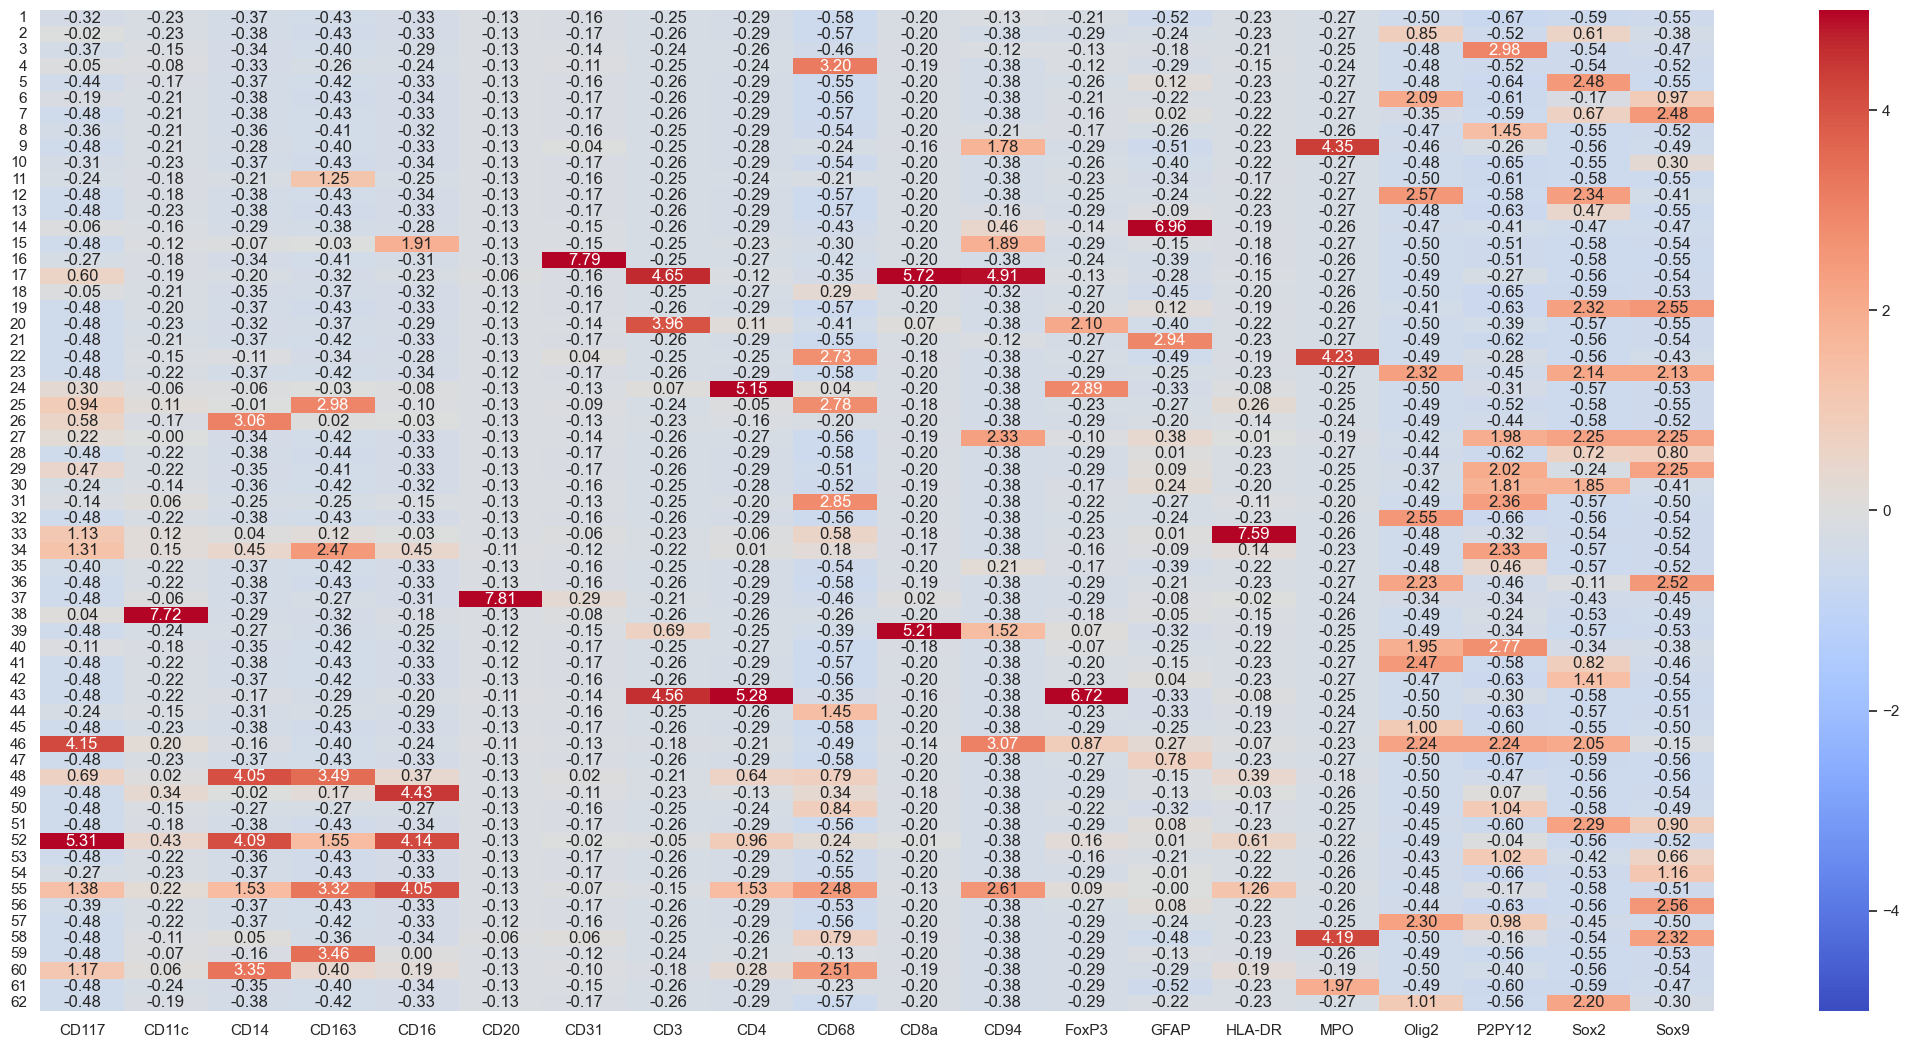

In [7]:
# The heatmap shows the normalized mean expression of each marker in each cluster, which can help to identify the cell types based on their marker expression profiles. 
pick_cluster_number = 62

kmeans = KMeans(n_clusters=pick_cluster_number, random_state=0).fit(sub_cell_expression)
cell_cluster_label=np.array(kmeans.labels_)
# print(Counter(cell_cluster_label))

cluster_centers_arr = np.array(kmeans.cluster_centers_)


cell_cluster = [str(i+1) for i in range(pick_cluster_number)]
adjust_cluster_centers_arr = cluster_centers_arr
normalized_array = (adjust_cluster_centers_arr - adjust_cluster_centers_arr.mean(axis=0)) / adjust_cluster_centers_arr.std(axis=0)


maker_column = ["CD117","CD11c","CD14","CD163","CD16","CD20","CD31","CD3","CD4","CD68","CD8a","CD94","FoxP3","GFAP","HLA-DR","MPO","Olig2","P2PY12","Sox2","Sox9"]
pca_temp = pd.DataFrame(data = normalized_array, index = cell_cluster, columns = np.array(maker_column))


celltype_list = []


all_celltype = ["Cancer Cell", "M2-like MG", "M1-like MG", "M2-like MDM", "M1-like MDM", "Tc cell", "Treg", "Th cell", "T other", "B cell", "Neutrophil", "NK cell", "CI Monocyte", "Int Monocyte", "Non-CI Monocyte", "Dendritic cell", "Endothlial cell", "Mast cell", "Astrocyte", "Undefined", "CD163 Monocyte"]

get_type_dict = {}
match_celltype = {}

for index, row in pca_temp.iterrows():
    if index == '11':
        get_type = 'CD163 Monocyte'
    else:
        get_type = define_cell_type(list(row))
    celltype_list.append(get_type)
    if index not in match_celltype:
        match_celltype[str(int(index) - 1)] = get_type
    if get_type not in get_type_dict.keys():
        get_type_dict[get_type] = [index]
    else:
        get_type_dict[get_type].append(index)
print("cluster num", pick_cluster_number, len(np.unique(celltype_list)), set(all_celltype).difference(set(np.unique(celltype_list))))
print(get_type_dict)


sns.set_style(style='white')
sns.set(rc={'figure.figsize':(27,13)})
sns.heatmap(pca_temp, annot=True,cmap="coolwarm",fmt=".2f", vmin=-5, vmax=5) # , vmin=-2, vmax=2
plt.show()



In [8]:
# Here is the final cell-type annotation result for brain dataset, which is based on the marker-defined cell-type assignments in the original paper figure
match_celltype

{'0': 'Undefined',
 '1': 'Cancer Cell',
 '2': 'Undefined',
 '3': 'M1-like MDM',
 '4': 'Cancer Cell',
 '5': 'Cancer Cell',
 '6': 'Cancer Cell',
 '7': 'Undefined',
 '8': 'Neutrophil',
 '9': 'Cancer Cell',
 '10': 'CD163 Monocyte',
 '11': 'Cancer Cell',
 '12': 'Cancer Cell',
 '13': 'NK cell',
 '14': 'NK cell',
 '15': 'Endothlial cell',
 '16': 'Tc cell',
 '17': 'M1-like MDM',
 '18': 'Cancer Cell',
 '19': 'Tc cell',
 '20': 'Astrocyte',
 '21': 'M1-like MDM',
 '22': 'Cancer Cell',
 '23': 'M1-like MDM',
 '24': 'M2-like MDM',
 '25': 'CI Monocyte',
 '26': 'Cancer Cell',
 '27': 'Cancer Cell',
 '28': 'Cancer Cell',
 '29': 'Cancer Cell',
 '30': 'M1-like MG',
 '31': 'Cancer Cell',
 '32': 'M2-like MDM',
 '33': 'M2-like MG',
 '34': 'NK cell',
 '35': 'Cancer Cell',
 '36': 'B cell',
 '37': 'Mast cell',
 '38': 'Tc cell',
 '39': 'Cancer Cell',
 '40': 'Cancer Cell',
 '41': 'Cancer Cell',
 '42': 'Treg',
 '43': 'M1-like MDM',
 '44': 'Cancer Cell',
 '45': 'Cancer Cell',
 '46': 'Astrocyte',
 '47': 'M2-like MDM'

### Superpixel importance scores

Next, we visualize the importance scores for test samples. Here, we select two samples, “BrM_046C2A” and “Glioma_073C1”, as examples; their additional results are shown in the supplementary material.

100%|██████████| 21/21 [00:00<00:00, 2396.16it/s]


[(1, 39), (2, 48), (3, 43), (4, 18), (5, 10), (6, 3), (7, 49), (8, 60), (9, 30), (10, 33), (11, 7), (12, 16), (13, 8), (14, 9), (15, 70), (16, 65), (17, 34), (18, 44), (19, 14), (20, 12), (21, 21), (22, 40), (23, 29), (24, 5), (25, 1), (26, 0), (27, 50), (28, 25), (29, 80), (30, 66), (31, 54), (32, 36), (33, 4), (34, 23), (35, 11), (36, 31), (37, 52), (38, 24), (39, 27), (40, 26), (41, 6), (42, 38), (43, 28), (44, 56), (45, 57), (46, 64), (47, 35), (48, 68), (49, 17), (50, 15), (51, 58), (52, 74), (53, 61), (54, 76), (55, 87), (56, 75), (57, 55), (58, 32), (59, 46), (60, 90), (61, 92), (62, 89), (63, 94), (64, 95), (65, 59), (66, 84), (67, 71), (68, 82), (69, 93), (70, 86), (71, 79), (72, 51), (73, 42), (74, 91), (75, 83), (76, 45), (77, 81), (78, 62), (79, 53), (80, 2), (81, 78), (82, 85), (83, 47), (84, 69), (85, 67), (86, 13), (87, 41), (88, 20), (89, 77), (90, 88), (91, 63), (92, 72), (93, 73), (94, 37), (95, 22), (96, 19)]


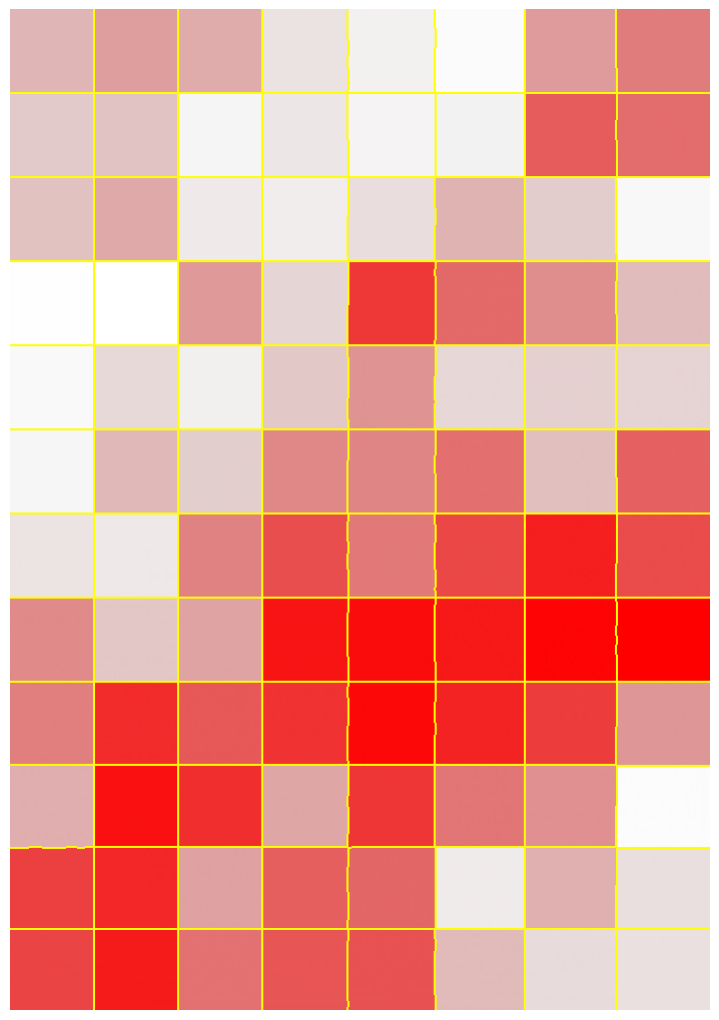

BrM_046C2A.tif [80, 76, 87, 90, 92, 89, 94, 95, 84, 82, 93, 86, 79, 91, 83, 81, 78, 85, 77, 88] [29, 54, 55, 60, 61, 62, 63, 64, 66, 68, 69, 70, 71, 74, 75, 77, 81, 82, 89, 90]


100%|██████████| 21/21 [00:00<00:00, 2262.76it/s]


[(1, 83), (2, 73), (3, 17), (4, 80), (5, 37), (6, 53), (7, 23), (8, 64), (9, 89), (10, 41), (11, 52), (12, 62), (13, 74), (14, 43), (15, 46), (16, 47), (17, 66), (18, 38), (19, 40), (20, 81), (21, 55), (22, 88), (23, 54), (24, 77), (25, 65), (26, 71), (27, 93), (28, 67), (29, 35), (30, 48), (31, 70), (32, 79), (33, 91), (34, 97), (35, 94), (36, 87), (37, 9), (38, 90), (39, 50), (40, 45), (41, 95), (42, 69), (43, 76), (44, 24), (45, 12), (46, 13), (47, 3), (48, 2), (49, 11), (50, 32), (51, 96), (52, 84), (53, 78), (54, 59), (55, 19), (56, 4), (57, 5), (58, 1), (59, 27), (60, 36), (61, 92), (62, 39), (63, 14), (64, 34), (65, 15), (66, 31), (67, 20), (68, 30), (69, 57), (70, 72), (71, 86), (72, 49), (73, 75), (74, 82), (75, 16), (76, 60), (77, 56), (78, 85), (79, 68), (80, 28), (81, 99), (82, 33), (83, 29), (84, 6), (85, 7), (86, 51), (87, 61), (88, 58), (89, 18), (90, 26), (91, 98), (92, 25), (93, 44), (94, 0), (95, 21), (96, 42), (97, 63), (98, 10), (99, 8), (100, 22)]


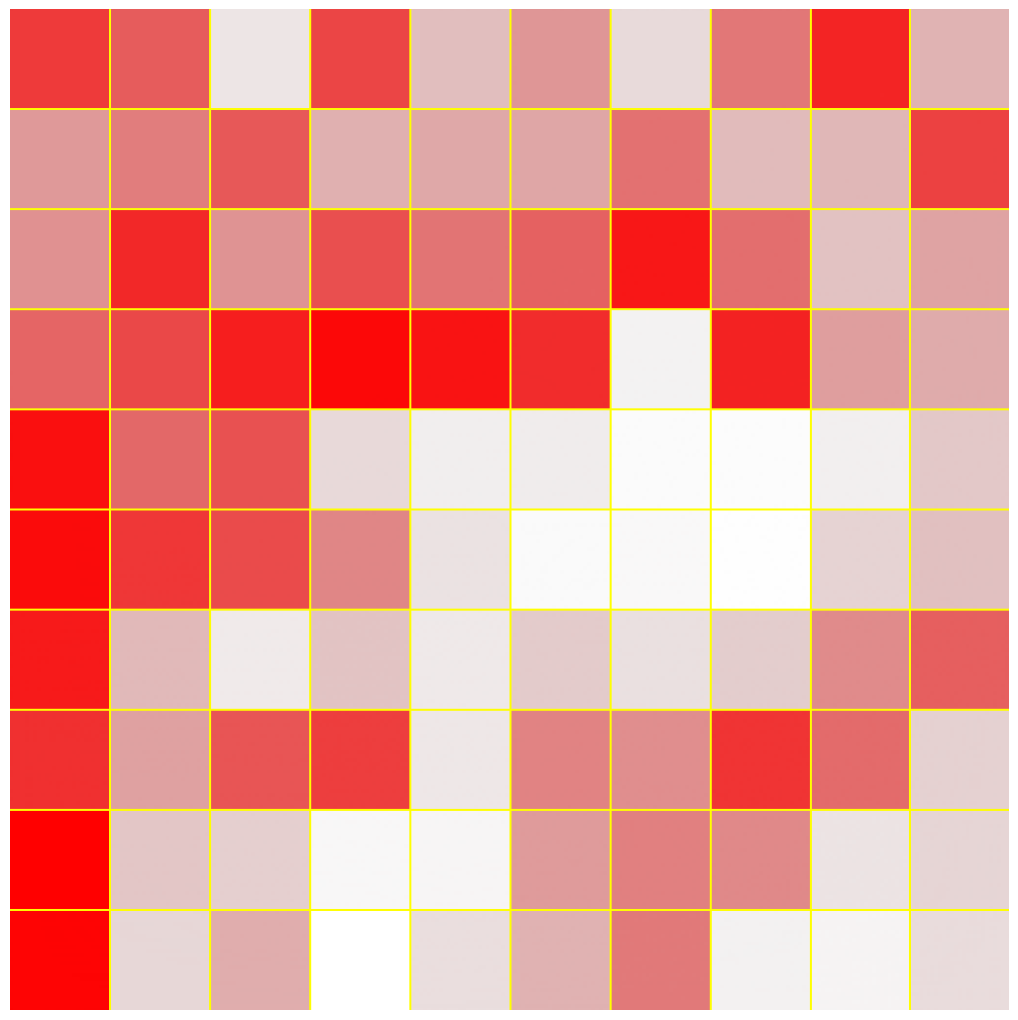

Glioma_073C1.tif [83, 80, 89, 81, 88, 93, 91, 97, 94, 87, 90, 95, 96, 84, 92, 86, 82, 85, 99, 98] [1, 4, 9, 20, 22, 27, 33, 34, 35, 36, 38, 41, 51, 52, 61, 71, 74, 78, 81, 91]


In [ ]:
import pandas as pd
from cellpose import models, io
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries

df_test = pd.read_csv("/brian_dataset/IMC_brain/fold8.csv", header=None)
df_labels = pd.read_csv("/brian_dataset/IMC_brain/labels.csv")

all_label_collect = {}
file_label = {}

for i in range(len(df_labels)):
    all_label_collect[np.array(df_labels)[i,0]] = 0 if np.array(df_labels)[i,1] == 'Brain Metastasis' else 1

for test_file in np.array(df_test)[:,0][np.where(np.array(df_test)[:,1] == 'test')[0]]:
    file_label[test_file] = all_label_collect[test_file]


numSegments = 100
get_name_list = list(file_label.keys())

for select_img_name in ['BrM_046C2A', 'Glioma_073C1']:
    select_top_pixel = 20
    img = io.imread('/brian_dataset/IMC_brain/sample_tiff/' + select_img_name + '.tif')
    img = np.transpose(img, (2, 1, 0))
    img = np.arcsinh(1. / 5 * img)
    img = img[:,:,[i for i in range(17)] + [18]]
    img = np.array(img)
    segments = slic(img, n_segments = numSegments, sigma = 5)

    # select_pixel_value = []
    get_max_segments = numSegments if numSegments < np.max(segments) else np.max(segments)
    with open('/brian_dataset/testset_superpixel/'+ select_img_name + '_pixelscore_toprank_' + str(select_top_pixel) + '.pkl','rb') as f:
        f_pixel_data = pickle.load(f)
    select_pixel_value = f_pixel_data ['superpixel_score']



    from colour import Color
    from PIL import ImageColor
    red = Color("white")
    colors = list(red.range_to(Color("red"),get_max_segments))

    image_3 = np.zeros((img.shape[0], img.shape[1], 3))

    pixel_value_rank = [sorted(select_pixel_value).index(x) for x in select_pixel_value]

    print([(i,pixel_value_rank[i - 1]) for i in range(1, len(pixel_value_rank)+1, 1)])

    allp = []
    for i in range(0,img.shape[0],1):
        sst = []
        for j in range(0,img.shape[1],1):
            pick_pixel_segment = numSegments if numSegments < segments[i][j] else segments[i][j]
            get_seg_num = pixel_value_rank[pick_pixel_segment-1]
            pixel_color = ImageColor.getcolor(colors[get_seg_num].hex, "RGB")
            image_3[i,j,0] , image_3[i,j,1], image_3[i,j,2] = int(pixel_color[0]), int(pixel_color[1]), int(pixel_color[2])
            sst.append([int(pixel_color[0]), int(pixel_color[1]), int(pixel_color[2])])

        allp.append(sst)
    allp = np.array(allp, dtype=np.uint8)

    fig = plt.figure("Superpixels -- segments")
    ax = fig.add_subplot(1, 1, 1)
    ax.imshow(mark_boundaries(allp, segments))
    font = {'family': 'serif',
            'color':  'black',
            'weight': 'normal',
            'size': 12,
            }
    collect_top_15 = []
    collect_pixel_value_rank = []
    for select_pixel_num in range(1, get_max_segments + 1, 1):
        if pixel_value_rank[select_pixel_num-1] >= get_max_segments - select_top_pixel:
            superpixel_idx = np.where(segments == select_pixel_num)
            collect_top_15.append(select_pixel_num)
            collect_pixel_value_rank.append(pixel_value_rank[select_pixel_num-1])
    plt.axis("off")
    # show the plots
    # plt.savefig("/Users/cookie/Downloads/plot_save/superpixel_rank/"+ select_img_name +"_superpixel_rank.png", dpi=300)
    plt.show()
    print(select_img_name + '.tif', collect_pixel_value_rank, collect_top_15)


Finally, we integrate cell-type annotations with the identified superpixels.

100%|██████████| 21/21 [00:00<00:00, 2288.81it/s]

0.021739130434782608 BrM_046C2A (1000, 699, 3) (1000, 699) (1000, 699, 21)


{29: ['Cancer Cell', 'NK cell', 'Undefined'], 55: ['M1-like MDM', 'NK cell', 'Tc cell', 'Undefined'], 54: ['Cancer Cell', 'M1-like MDM', 'M1-like MG', 'NK cell', 'Tc cell', 'Undefined'], 61: ['M2-like MG', 'NK cell', 'Tc cell', 'Undefined'], 62: ['Astrocyte', 'CD163 Monocyte', 'M1-like MDM', 'M2-like MDM', 'NK cell', 'Tc cell', 'Undefined'], 64: ['CI Monocyte', 'NK cell', 'Tc cell', 'Treg', 'Undefined'], 63: ['M1-like MDM', 'M2-like MDM', 'NK cell', 'Tc cell', 'Treg', 'Undefined'], 60: ['M2-like MDM', 'NK cell', 'Treg'], 69: ['CD163 Monocyte', 'M1-like MDM', 'NK cell', 'Treg', 'Undefined'], 70: ['CD163 Monocyte', 'M1-like MDM', 'M2-like MDM', 'NK cell', 'Undefined'], 71: ['CD163 Monocyte', 'M1-like MDM', 'NK cell', 'Tc cell', 'Treg', 'Undefined'], 68: ['CD163 Monocyte', 'M2-like MDM', 'Treg', 'Undefined'], 66: ['Astrocyte', 'NK cell', 'Undefined'], 74: ['Astrocyte', 'CI Monocyte', 'M2-like MG', 'NK cell', 'Tc cell', 'Undefined'], 75: ['CI Monocyte', 'M1-like MDM', 'M2-like MDM', 'Neutr

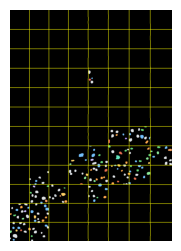

100%|██████████| 21/21 [00:00<00:00, 2450.15it/s]

0.043478260869565216 Glioma_073C1 (1000, 998, 3) (1000, 998) (1000, 998, 21)


{4: ['Astrocyte', 'Cancer Cell', 'M1-like MDM', 'M2-like MDM'], 9: ['CD163 Monocyte', 'Cancer Cell', 'M2-like MDM', 'Undefined'], 1: ['Astrocyte', 'Cancer Cell', 'NK cell', 'Undefined'], 20: ['Astrocyte', 'CD163 Monocyte', 'Undefined'], 22: ['CD163 Monocyte', 'CI Monocyte', 'Cancer Cell', 'M1-like MDM', 'Non-CI Monocyte', 'Undefined'], 27: ['NK cell', 'Neutrophil', 'Tc cell', 'Undefined'], 33: ['Astrocyte', 'Cancer Cell', 'M2-like MDM', 'Undefined'], 34: ['Astrocyte', 'Cancer Cell', 'M1-like MDM', 'M2-like MDM', 'Undefined'], 35: ['Cancer Cell', 'M1-like MDM', 'M2-like MDM', 'Undefined'], 36: ['Astrocyte', 'CD163 Monocyte', 'Undefined'], 38: ['Cancer Cell', 'NK cell', 'Tc cell', 'Undefined'], 41: ['Astrocyte', 'Cancer Cell', 'Non-CI Monocyte', 'Undefined'], 51: ['Astrocyte', 'CD163 Monocyte', 'Cancer Cell', 'Undefined'], 52: ['Astrocyte', 'Cancer Cell', 'NK cell', 'Undefined'], 61: ['Astrocyte', 'Cancer Cell', 'Undefined'], 71: ['Astrocyte', 'Cancer Cell', 'M1-like MDM', 'Undefined'], 

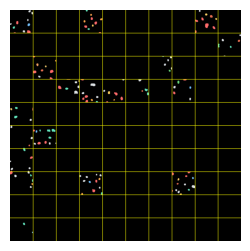

In [ ]:
from cellpose import models, io
from cellpose import dynamics
from scipy.ndimage import find_objects
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float

# Base colors for groups (0–255 RGB)
celltype_to_rgb = {
    # Tumors / malignant
    "Cancer Cell":        [255, 107, 107],   # #FF6B6B

    # Myeloid: macrophage / MDM
    "M1-like MDM":        [255, 169, 77],    # #FFA94D
    "M2-like MDM":        [255, 209, 102],   # #FFD166

    # Myeloid: microglia
    "M1-like MG":         [177, 151, 252],   # #B197FC
    "M2-like MG":         [208, 191, 255],   # #D0BFFF

    # Lymphoid: T cells
    "Tc cell":            [105, 219, 124],   # #69DB7C
    "Treg":               [140, 233, 154],   # #8CE99A

    # Lymphoid: NK / B
    "NK cell":            [116, 192, 252],   # #74C0FC
    "B cell":             [165, 216, 255],   # #A5D8FF

    # Monocytes
    "CD163 Monocyte":     [231, 111, 81],    # #E76F51
    "CI Monocyte":        [244, 162, 97],    # #F4A261
    "Non-CI Monocyte":    [233, 196, 106],   # #E9C46A
    "Int Monocyte":       [205, 190, 112],   # #CDBE70

    # Other immune
    "Neutrophil":         [206, 212, 218],   # #CED4DA
    "Mast cell":          [247, 131, 172],   # #F783AC

    # Stromal
    "Astrocyte":          [99, 230, 190],    # #63E6BE
    "Endothlial cell":    [102, 217, 232],   # #66D9E8

    # Fallback
    "Undefined":          [222, 226, 230],   # #DEE2E6
}


match_celltype = {'0': 'Undefined',
 '1': 'Cancer Cell',
 '2': 'Undefined',
 '3': 'M1-like MDM',
 '4': 'Cancer Cell',
 '5': 'Cancer Cell',
 '6': 'Cancer Cell',
 '7': 'Undefined',
 '8': 'Neutrophil',
 '9': 'Cancer Cell',
 '10': 'CD163 Monocyte',
 '11': 'Cancer Cell',
 '12': 'Cancer Cell',
 '13': 'NK cell',
 '14': 'NK cell',
 '15': 'Endothlial cell',
 '16': 'Tc cell',
 '17': 'M1-like MDM',
 '18': 'Cancer Cell',
 '19': 'Tc cell',
 '20': 'Astrocyte',
 '21': 'M1-like MDM',
 '22': 'Cancer Cell',
 '23': 'M1-like MDM',
 '24': 'M2-like MDM',
 '25': 'CI Monocyte',
 '26': 'Cancer Cell',
 '27': 'Cancer Cell',
 '28': 'Cancer Cell',
 '29': 'Cancer Cell',
 '30': 'M1-like MG',
 '31': 'Cancer Cell',
 '32': 'M2-like MDM',
 '33': 'M2-like MG',
 '34': 'NK cell',
 '35': 'Cancer Cell',
 '36': 'B cell',
 '37': 'Mast cell',
 '38': 'Tc cell',
 '39': 'Cancer Cell',
 '40': 'Cancer Cell',
 '41': 'Cancer Cell',
 '42': 'Treg',
 '43': 'M1-like MDM',
 '44': 'Cancer Cell',
 '45': 'Cancer Cell',
 '46': 'Astrocyte',
 '47': 'M2-like MDM',
 '48': 'M2-like MG',
 '49': 'M1-like MG',
 '50': 'Cancer Cell',
 '51': 'M2-like MDM',
 '52': 'Cancer Cell',
 '53': 'Cancer Cell',
 '54': 'M2-like MDM',
 '55': 'Cancer Cell',
 '56': 'Cancer Cell',
 '57': 'Cancer Cell',
 '58': 'Non-CI Monocyte',
 '59': 'M2-like MDM',
 '60': 'Neutrophil',
 '61': 'Cancer Cell'}

celltype_list = ['Astrocytes', 'M1-like MDMs', 'M2-like MDMs', 'Tc cell', 'B cell','undefined']


data_path_str = '/brian_dataset/MASKRCNN/stage3_test/stage3_test/'
path = "/brian_dataset/MASKRCNN/submit_folder_1/update/" 


csv_files = [f for f in os.listdir('/brian_dataset/testset_superpixel') if f.endswith("_pixelscore_toprank_20.pkl")]
count = 0

for visit_file in ['BrM_046C2A', 'Glioma_073C1']:
    count += 1
    get_pure_file_name = visit_file.split("_pixelscore_toprank_20.pkl")[0]
    if get_pure_file_name + '.tif' in trace_cell_col.keys():
        im_ori_tif = io.imread('/brian_dataset/IMC_brain/sample_tiff/' + get_pure_file_name + '.tif')
        im = io.imread(data_path_str + get_pure_file_name + '/images/' + get_pure_file_name + '.png') # nucli image?!
        df_getcell = pd.read_csv(path + get_pure_file_name + '_update.csv') # cell detect number and cell type (cluster) match
        im_mask = io.imread('/brian_dataset/MASKRCNN/submit_folder_1/' + get_pure_file_name + '_mask.tif') # cell dectect mask
        
        
        im_ori_tif = np.transpose(im_ori_tif, (2, 1, 0))
        print(count/len(csv_files), get_pure_file_name, im.shape, im_mask.shape, im_ori_tif.shape)


        numSegments = 100
        im_ori_tif = np.arcsinh(1. / 5 * im_ori_tif)
        im_ori_tif = im_ori_tif[:,:,[i for i in range(17)] + [18]]
        segments = slic(im_ori_tif, n_segments = numSegments, sigma = 5)

        sub_cell_cluster_label = df_getcell['cell_type']
        sub_ims_seg_center = np.array(ims_seg_center[get_pure_file_name + '.tif'])
        # print(get_pure_file_name, len(ims_seg_center[get_pure_file_name + '.tif']),get_pure_file_name + '_update.csv', len(sub_cell_cluster_label))
        top_pixel_dict = pickle.load(open("/brian_dataset/testset_superpixel/" + get_pure_file_name + "_pixelscore_toprank_20.pkl", "rb"))
        top_pixel_dict = top_pixel_dict['top_rank']


        allp = []
        celltype_dict = {}
        for i in range(0,im.shape[0],1):
            sst = []
            for j in range(0,im.shape[1],1):
                if im_mask[i][j] != 0:
                    if (segments[i][j] in top_pixel_dict):
                        get_pixel_cell_type = df_getcell.loc[df_getcell["cell_number"] == im_mask[i][j], "cell_type"].values[0]
                        sst.append(celltype_to_rgb[get_pixel_cell_type])
                        if segments[i][j] not in celltype_dict:
                            celltype_dict[segments[i][j]] = [get_pixel_cell_type]
                        else:
                            temp_celltype_set = celltype_dict[segments[i][j]]
                            temp_celltype_set.append(get_pixel_cell_type)
                            celltype_dict[segments[i][j]] = list(np.unique(temp_celltype_set))

                    else:
                        sst.append([0, 0, 0])
                else:
                    sst.append([0,0,0])

            allp.append(sst)
        allp = np.array(allp, dtype=np.uint8)
        print(celltype_dict)

        fig = plt.figure("Superpixels -- segments", figsize=(3, 3)) # , figsize=(3, 3)
        ax = fig.add_subplot(1, 1, 1)
        ax.imshow(mark_boundaries(allp, segments))
        # ax.imshow(allp)
        from skimage.util import img_as_float
        vis_img = mark_boundaries(
            img_as_float(allp),
            segments,
            color=(1, 1, 0),   # yellow boundary
            mode="thick"
        )


        font = {'family': 'serif',
        'color':  'red',
        'weight': 'normal',
        'size': 12,
        } 
        plt.axis("off")

        plt.show()




### Kaplan-Meier analysis for brain tumors dataset

/Users/cookie/miniconda3/envs/tensorflow/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/cookie/miniconda3/envs/tensorflow/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


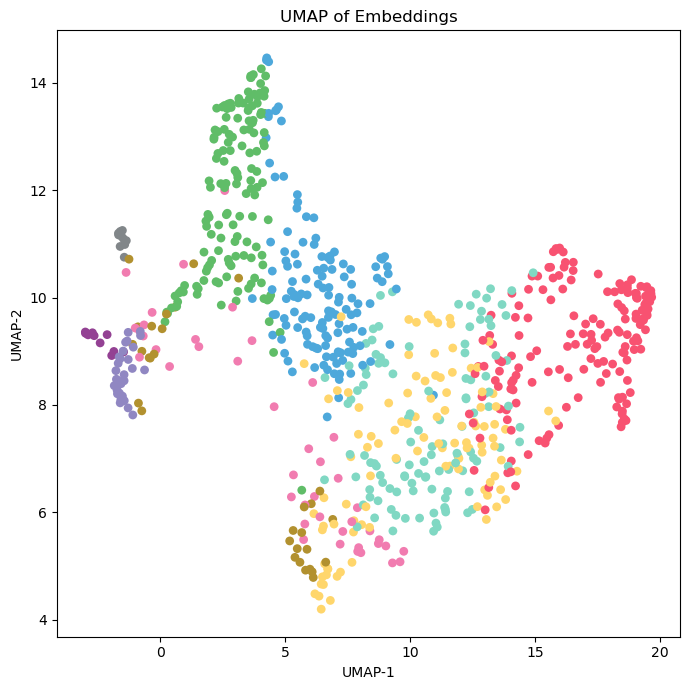

Cluster:  0


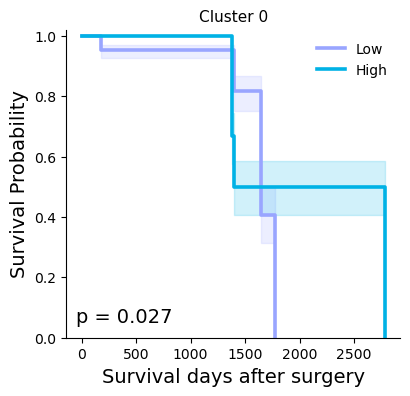

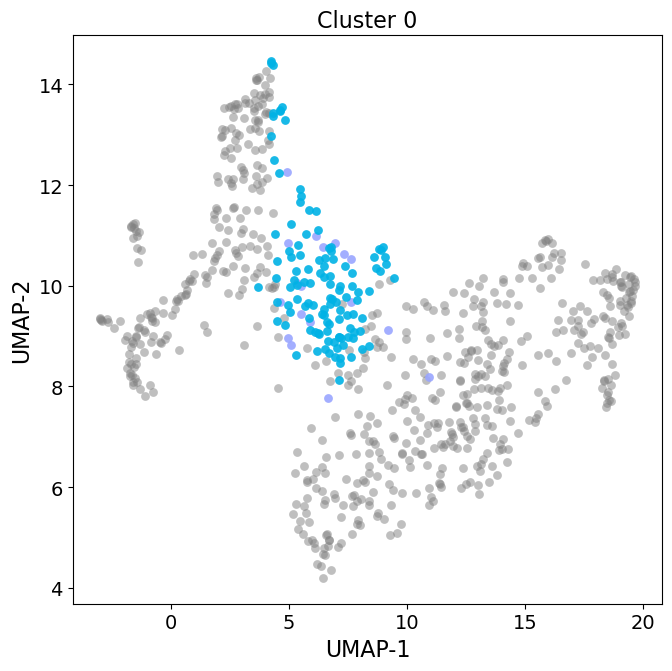

Cluster:  1


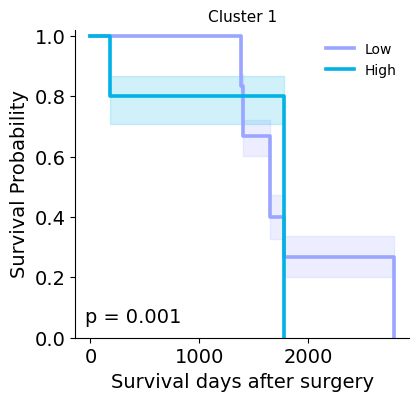

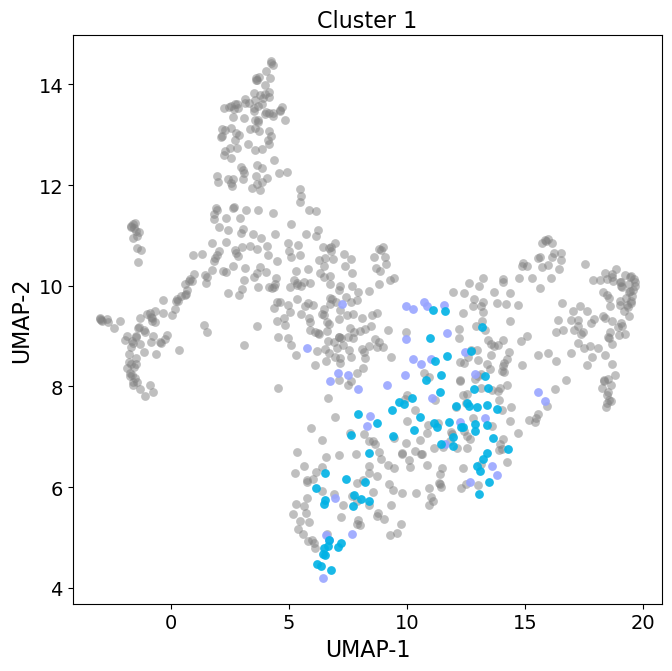

Cluster:  2


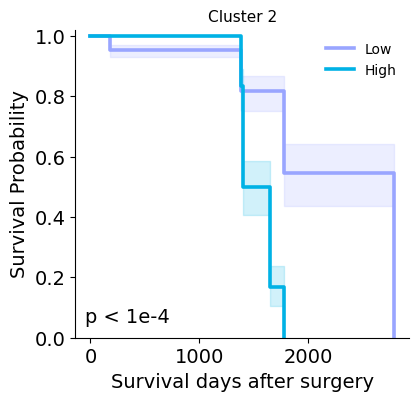

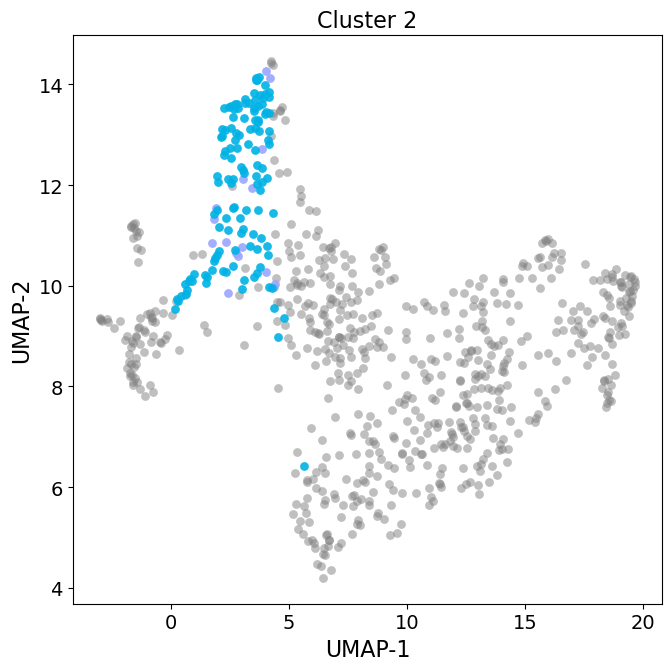

Cluster:  3


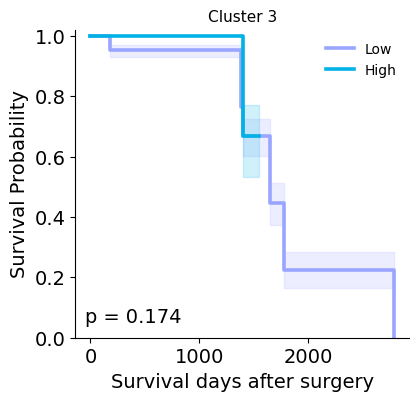

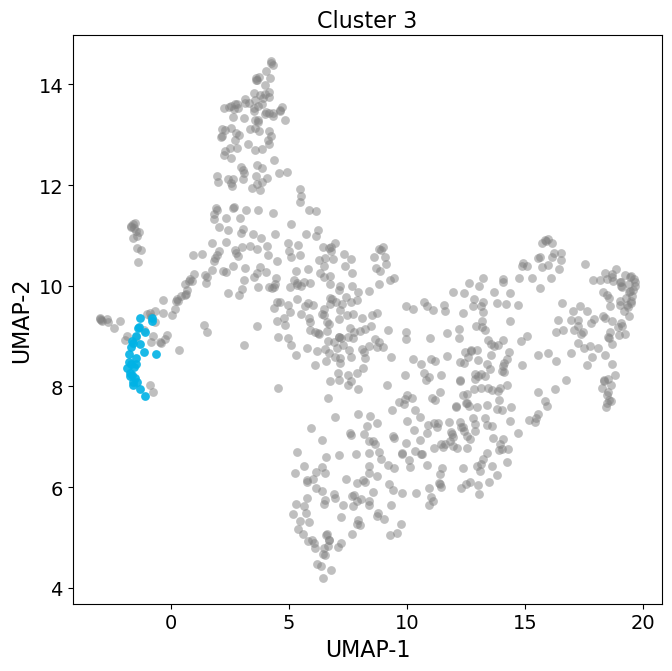

Cluster:  4


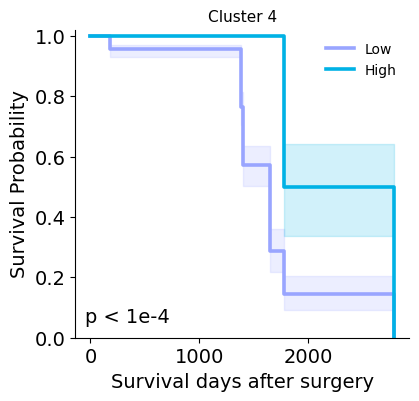

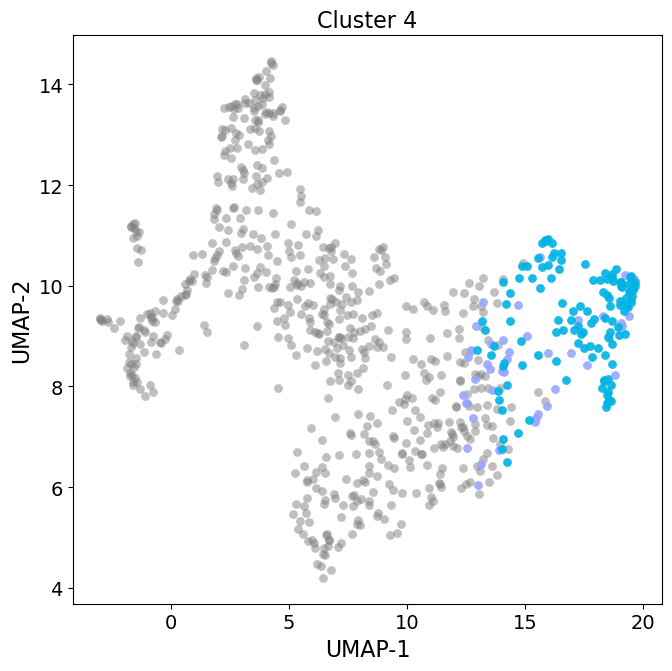

Cluster:  5


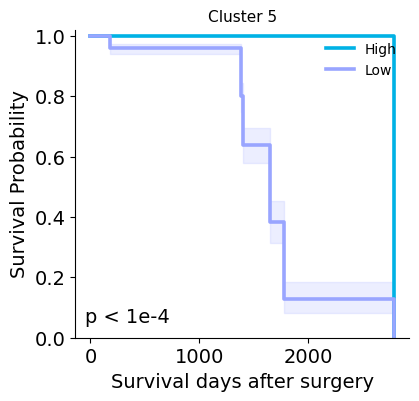

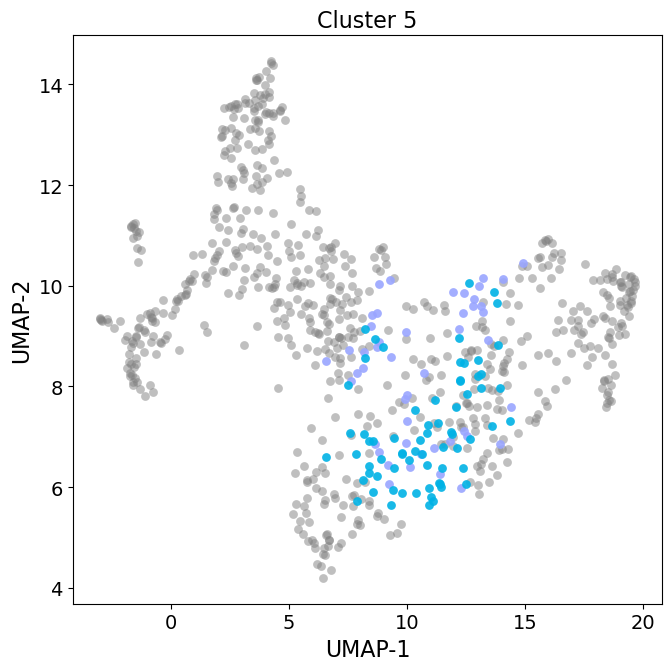

Cluster:  6


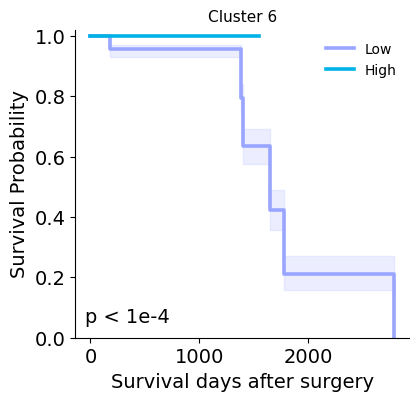

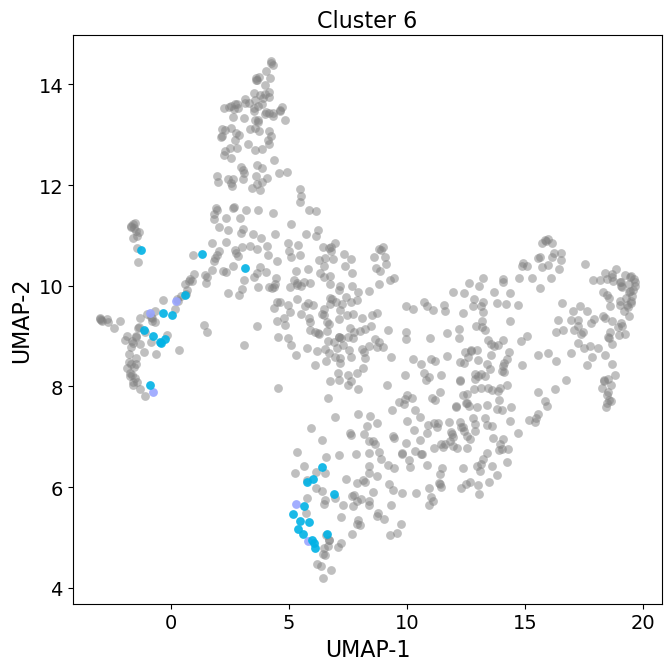

Cluster:  7


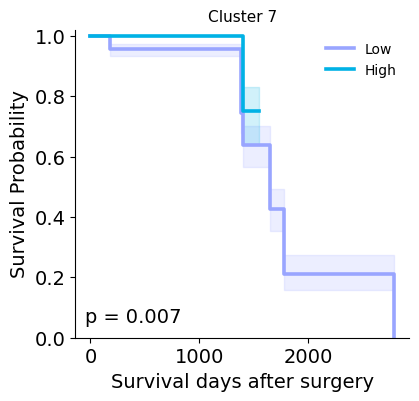

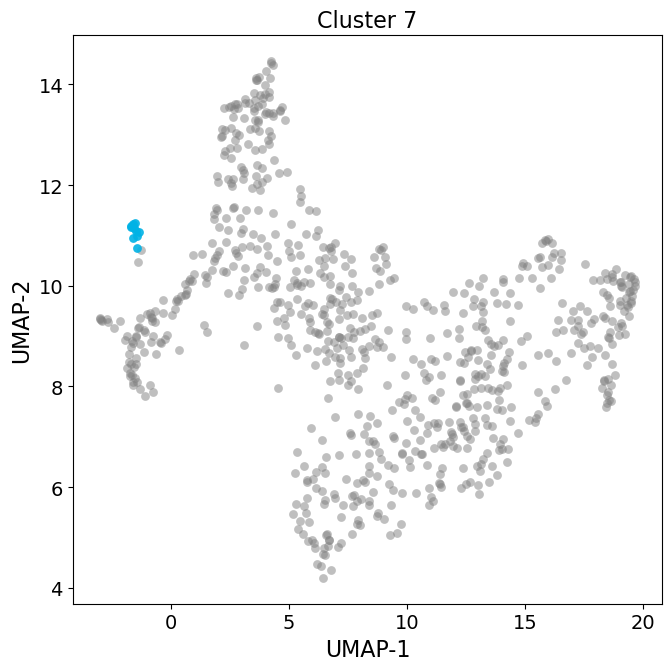

Cluster:  8


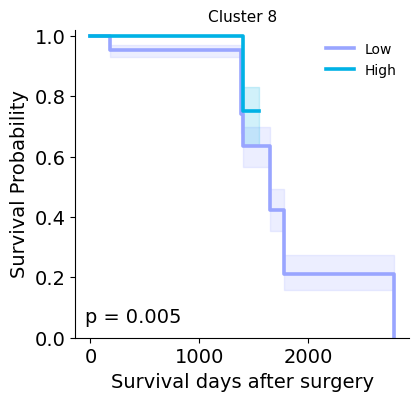

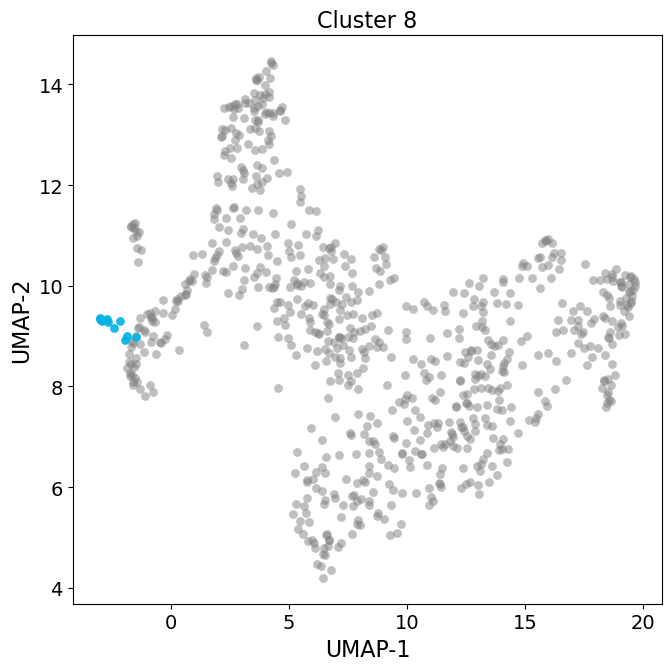

Cluster:  9


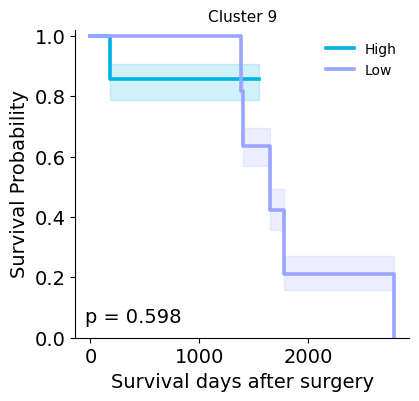

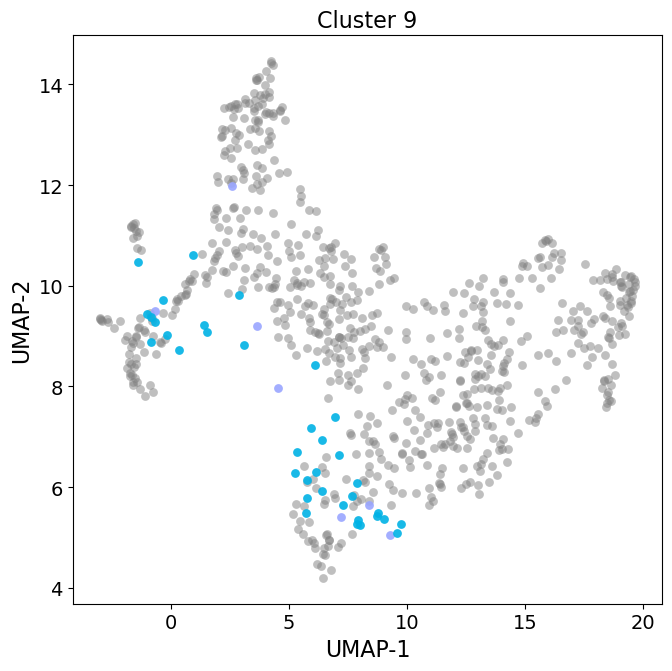

In [ ]:
# lifetime high-low frequency plot for (BrM and GBM)

import pickle
import numpy as np
import pandas as pd
import random
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve,auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from collections import Counter


import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter
from lifelines.datasets import load_waltons
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test


def plot_umap_high_low_for_cluster(
    umap_emb,
    superpixel_label,
    instence_id,
    cluster_id,
    low_freq,
    high_freq,
    colors = {'High': "#00B2E5", 'Low': "#99A5FF"},
    bg_color="gray",
    s_bg=40,
    s_fg=40,
    alpha_bg=0.5,
    alpha_fg=0.9,
    get_cluster_title=None,
):
    import numpy as np
    import matplotlib.pyplot as plt

    inst = np.array(instence_id)

    # mask for other background clusters
    bg_mask = (superpixel_label != cluster_id)

    # mask for the current cluster
    fg_mask = (superpixel_label == cluster_id)

    # define high and low frequency masks based on the instance IDs
    high_mask = fg_mask & np.isin(inst, high_freq)
    low_mask  = fg_mask & np.isin(inst, low_freq)

    import matplotlib as mpl

    mpl.rcParams.update({
        "font.size": 16,       
        "axes.titlesize": 16,    
        "axes.labelsize": 16,     
        "xtick.labelsize": 14,    
        "ytick.labelsize": 14,    
        "legend.fontsize": 14,
    })

    plt.figure(figsize=(7, 7))

    # set gray dots for background clusters
    plt.scatter(
        umap_emb[bg_mask, 0], umap_emb[bg_mask, 1],
        c=bg_color, s=s_bg, alpha=alpha_bg, linewidths=0
    )

    # set low
    plt.scatter(
        umap_emb[low_mask, 0], umap_emb[low_mask, 1],
        c=colors["Low"], s=s_fg, alpha=alpha_fg, linewidths=0,
        label=f"Low (n={low_mask.sum()})"
    )

    # set high
    plt.scatter(
        umap_emb[high_mask, 0], umap_emb[high_mask, 1],
        c=colors["High"], s=s_fg, alpha=alpha_fg, linewidths=0,
        label=f"High (n={high_mask.sum()})"
    )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.title(f"Cluster {cluster_id}")
    plt.tight_layout()
    plt.show()


with open('/brian_dataset/MICRON_output/imc_brain_testimg_dict_seg100_sel30cleanchannellocfixcrop2_fold8.pkl', 'rb') as handle:
    unserialized_data = pickle.load(handle)

df_test = pd.read_csv("/brian_dataset/MICRON_output/fold8.csv", header=None)
df_labels = pd.read_csv("/brian_dataset/MICRON_output/labels.csv")

all_label_collect = {}

for i in range(len(df_labels)):
    all_label_collect[np.array(df_labels)[i,0]] = 0 if np.array(df_labels)[i,1] == 'Brain Metastasis' else 1

file_label = {}
for test_file in np.array(df_test)[:,0][np.where(np.array(df_test)[:,1] == 'test')[0]]:
    file_label[test_file] = all_label_collect[test_file]


# Load the Excel file
file_path = "/brian_dataset/IMC_brain/Clinical_Data_GBM_BrM.xlsx"
df_excel = pd.read_excel(file_path)



all_file = list(file_label.keys())
all_embed = np.empty((0,51200), float)
label_collect_list = []
pixel_time = []
no_time_ID = ['Glioma_007C1', 'Glioma_007C2', 'Glioma_086C1', 'Glioma_086C2', 'Glioma_086N', 'Glioma_099C', 'Glioma_099N']
instence_id = []

for i in all_file:
    if i not in no_time_ID:
        crop_pick = pickle.load(open('/brian_dataset/testset_superpixel/'+ i +"_pixelscore_toprank_20.pkl", "rb"))
        crop_pick = [x - 1 for x in crop_pick['top_rank']]
        sruvial_day = df_excel.loc[df_excel['Image ID'] == i, 'OS event (days post surgery)'].values[0]
        sruvial_day = sruvial_day.split('(')[1]
        sruvial_day = sruvial_day.split(')')[0]
        for sub_crop in crop_pick:
            label_collect_list.append(0 if all_label_collect[i] == 0 else 1)
            pixel_time.append(int(sruvial_day))
        
        probility_percent = unserialized_data[i + '.tif probility']
        probility_percent[probility_percent == 0] = 0.00000001
        probility_percent = np.array([j/i for i, j in zip(np.sum(probility_percent,axis= 1), probility_percent)]) 
        select_idx = np.where(probility_percent[:,file_label[i]]>0)[0]
        temp_embed = unserialized_data[i + '.tif']
        temp_embed = temp_embed[select_idx[crop_pick]]
        all_embed = np.append(all_embed, temp_embed, axis=0)
        instence_id += [i + '.tif' for _ in range(len(temp_embed))]

from sklearn.cluster import KMeans
from sklearn.metrics import roc_curve,auc

cluster_num_set = 10
sample_frequency = np.zeros((len(np.unique(instence_id)), cluster_num_set), float)
kmeans = KMeans(n_clusters=cluster_num_set, random_state=0).fit(all_embed)
superpixel_label = kmeans.labels_

# plot k-mean umap:all_embed/superpixel_label
import umap
from sklearn.decomposition import PCA

pca = PCA(n_components=30, random_state=42)
embed_pca = pca.fit_transform(all_embed)

umap_emb = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    spread=2.0,
    metric="euclidean",
    random_state=42,
).fit_transform(embed_pca)

# Setting plot colors for clusters
cluster_color_dict = {
    0: "#4DA8DB",
    1: "#FFD66C",
    2: "#60BD68",
    3: "#9087C2",
    4: "#F85271",
    5: "#80D8C3",
    6: "#B2912F",
    7: "#818689",
    8: "#934193",
    9: "#F17CB0",
}
from matplotlib.colors import ListedColormap
cmap_custom = ListedColormap([cluster_color_dict[i] for i in range(cluster_num_set)])

plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    umap_emb[:, 0],
    umap_emb[:, 1],
    c=superpixel_label,
    cmap=cmap_custom,   
    vmin=0,
    vmax=cluster_num_set - 1, # 0..9
    s=40,
    alpha=1,
    linewidths=0,
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of Embeddings")

plt.tight_layout()
plt.show()



remain_id = np.unique(instence_id)

for per_id_idx in range(0, len(remain_id), 1):
    get_id_idx = np.where(np.array(instence_id) == remain_id[per_id_idx])[0]
    sub_superpixel_label = superpixel_label[get_id_idx]
    for assign_label in sub_superpixel_label:
        sample_frequency[per_id_idx][assign_label] += 1

ID_split_dict = {}
cluster_to_low = {}
cluster_to_high = {}
cluster_all_list = [clus_num for clus_num in range(10)]




for per_column in cluster_all_list: 
    per_freq = sample_frequency[:,per_column]
    sort_freq_idx = np.argsort(per_freq)
    print("Cluster: ", per_column)
    new_id = remain_id[sort_freq_idx]
    tile = {"10th": 4, "25th": 10, "50th": 20, "75th": 29, "90th": 35}

    plt.figure(figsize=(25, 4))

    count = 1
    for set_tile in ["75th"]:

        cut_off = tile[set_tile]
        low_freq = new_id[:cut_off]
        high_freq = new_id[cut_off:]
        cluster_to_low[per_column] = set(low_freq)
        cluster_to_high[per_column] = set(high_freq)



        ID_split_dict[str(per_column) + '_' +  set_tile + '_low'] = low_freq

        ID_split_dict[str(per_column) + '_' +  set_tile + '_high'] = high_freq


        group_label = []
        for i in instence_id:
            if i in low_freq:
                group_label.append('Low')
            elif i in high_freq:
                group_label.append('High')


        # Kaplan-Meier survival analysis
        kmf = KaplanMeierFitter()
        d = {'T': pixel_time, 'E': label_collect_list,'group':group_label}
        data = pd.DataFrame(data=d)

        groups = data['group'].unique()
        colors = {'High': "#00B2E5", 'Low': "#99A5FF"}


        plt.subplot(1,5,count)

        ax = plt.gca()

        # setting plot style
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.25)
        ax.set_ylim(0, 1.02)

        LINEWIDTH = 2.6
        CI_ALPHA = 0.18

        censor_styles = {"marker": "|", "ms": 10, "mew": 2}

        for group in groups:
            group_data = data[data['group'] == group]

            n = len(group_data)
            kmf.fit(durations=group_data['T'], event_observed=group_data['E'], label=f"{group}")
            kmf.plot_survival_function(
                ax=ax,
                color=colors[group],
                linewidth=LINEWIDTH,
                ci_show=True,
                ci_alpha=CI_ALPHA,
                censor_styles=censor_styles
            )

        results = logrank_test(data[data['group'] == 'High']['T'], data[data['group'] == 'Low']['T'],
                           event_observed_A=data[data['group'] == 'High']['E'], event_observed_B=data[data['group'] == 'Low']['E'])
        p_value = results.p_value

        if p_value < 1e-4:
            p_text = "p < 1e-4"
        else:
            p_text = f"p = {p_value:.3f}"

        ax.text(
            0.03, 0.05, p_text,
            transform=ax.transAxes,
            fontsize=14,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85)
        )

        ax.set_title(f"Cluster {per_column}", fontsize=11, pad=6) #  ({set_tile})

        if count == 1:
            plt.xlabel('Survival days after surgery', fontsize=14)
            plt.ylabel('Survival Probability', fontsize=14)
        else:
            plt.xlabel('')
            plt.ylabel('')
            ax.set_yticklabels([])  
        # plt.legend()
        ax.legend(loc="upper right", frameon=False, fontsize=10)
        count += 1
    plt.show()

    plot_umap_high_low_for_cluster(
    umap_emb=umap_emb,
    superpixel_label=superpixel_label,
    instence_id=instence_id,
    cluster_id=per_column,
    low_freq=low_freq,
    high_freq=high_freq,
    get_cluster_title=per_column, 
    )
